In [62]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Load the cleaned dataset
file_path = 'maryland_2020_with_weather.csv'  # Adjust file path as needed
pollutant_weather_data = pd.read_csv(file_path)

# Step 1: Filter the data for a specific pollutant (e.g., 'Ozone')
pollutant_name = 'co'  # Change this to 'pm25', 'no2', etc.
pollutant_weather_data_filtered = pollutant_weather_data[pollutant_weather_data['parameter'] == pollutant_name]

# Step 2: Clean the filtered data

# Convert 'datetime' column to datetime format
pollutant_weather_data_filtered.loc[:, 'datetime'] = pd.to_datetime(pollutant_weather_data_filtered['datetime'], format='%Y-%m-%d %H:%M:%S')

# Convert non-numeric entries to NaN for each column in the feature set
features = ['temp (°C)', 'relative humidity (%)', 'precipitation (mm)', 'wind speed (km/h)', 'pressure (hPa)']
for column in features:
    pollutant_weather_data_filtered.loc[:, column] = pd.to_numeric(pollutant_weather_data_filtered[column], errors='coerce')

# Fill NaN values in features with column means
pollutant_weather_data_filtered.loc[:, features] = pollutant_weather_data_filtered[features].fillna(pollutant_weather_data_filtered[features].mean())

# Step 3: Feature Selection and Target Variable
X = pollutant_weather_data_filtered[features]
y = pollutant_weather_data_filtered['value']  # The pollutant concentration value

# Step 4: Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 5: Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 6: Train a Ridge Regression model
ridge_model = Ridge(alpha=1.0)  # Regularization strength
ridge_model.fit(X_train_scaled, y_train)

# Step 7: Make predictions
y_pred = ridge_model.predict(X_test_scaled)

# Step 8: Evaluate the model's performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Display the results
print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared: {r2}")


Mean Squared Error (MSE): 0.028313858161138388
R-squared: 0.07357807523469262


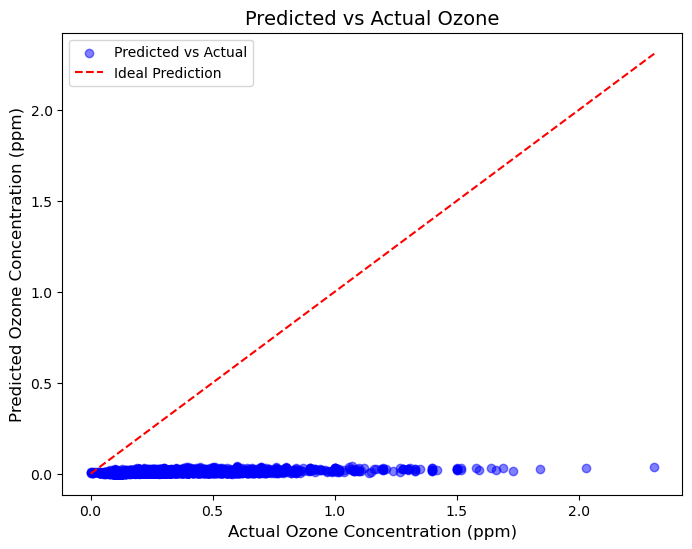

In [64]:
import matplotlib.pyplot as plt

# Step 1: Make predictions on the test data
y_pred = rf_model.predict(X_test_scaled)

# Step 2: Plot the predicted values vs actual values with improvements
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5, label='Predicted vs Actual')

# Plot the ideal line (y = x)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label='Ideal Prediction')

# Adding labels and title
plt.xlabel('Actual Ozone Concentration (ppm)', fontsize=12)  # Modify units as necessary
plt.ylabel('Predicted Ozone Concentration (ppm)', fontsize=12)  # Modify units as necessary
plt.title('Predicted vs Actual Ozone', fontsize=14)

# Adding a legend
plt.legend()

# Show the plot
plt.show()


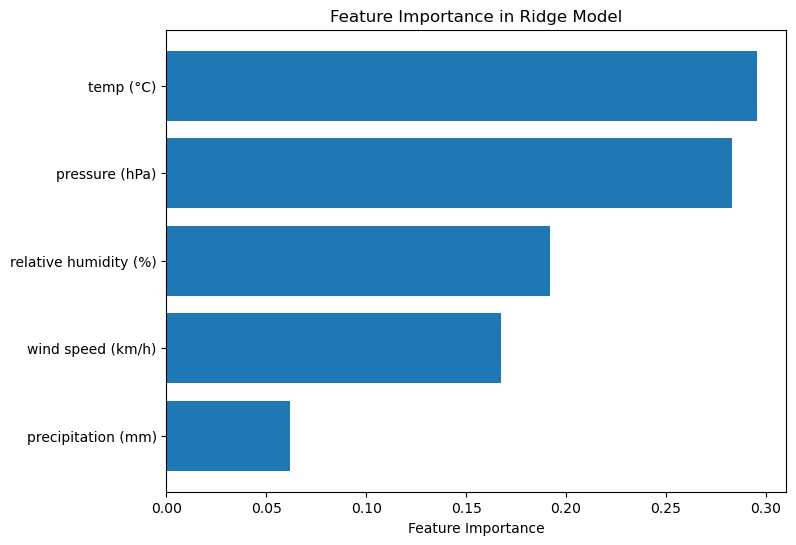

In [58]:
# Step 1: Get the feature importances from the trained model
importances = rf_model.feature_importances_

# Step 2: Sort the features by importance
sorted_idx = importances.argsort()

# Step 3: Plot the feature importances
plt.figure(figsize=(8, 6))
plt.barh(range(len(features)), importances[sorted_idx], align='center')
plt.yticks(range(len(features)), [features[i] for i in sorted_idx])
plt.xlabel('Feature Importance')
plt.title('Feature Importance in Ridge Model')
plt.show()
